# Machine Learning-Based Fraud Detection for Financial Transactions

**Capstone Project – Pillar 5**  
**Author:** Jefferson Capistrano  

## Business Objective
The objective of this project is to develop and evaluate machine learning models that can identify potentially fraudulent credit card transactions while minimizing disruption to legitimate customers.

## Machine Learning Task
This is a supervised binary classification problem:

- **0 = Legitimate transaction**
- **1 = Fraudulent transaction**

Because fraudulent transactions represent a very small percentage of total transactions, the project will focus not only on accuracy but also on Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

## Business Relevance
An effective fraud detection model can help financial institutions:
- Detect more fraudulent transactions
- Reduce potential financial losses
- Prioritize suspicious transactions for investigation
- Reduce unnecessary manual reviews
- Minimize false alerts affecting legitimate customers

In [ ]:
# Install additional packages required later in the project
!pip -q install xgboost shap imbalanced-learn

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


In [ ]:
# Download the Credit Card Fraud Detection dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(dataset_url)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
print("Dataset shape:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape:
(284807, 31)

Number of rows: 284807
Number of columns: 31


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print("\nData types:")
print(df.dtypes.value_counts())


Data types:
float64    30
int64       1
Name: count, dtype: int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [ ]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

if len(missing_summary) == 0:
    print("No missing values detected in the dataset.")
else:
    display(missing_summary)

No missing values detected in the dataset.


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:",
      round((duplicate_count / len(df)) * 100, 4), "%")

Number of duplicate rows: 1081
Percentage of duplicate rows: 0.3796 %


In [ ]:
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Transaction Type": ["Legitimate", "Fraudulent"],
    "Count": [class_counts.get(0, 0), class_counts.get(1, 0)],
    "Percentage": [
        class_percentages.get(0, 0),
        class_percentages.get(1, 0)
    ]
})

class_summary

,Transaction Type,Count,Percentage
0,Legitimate,284315,99.827251
1,Fraudulent,492,0.172749


In [ ]:
fraud_rate = df["Class"].mean() * 100

print(f"Fraud rate: {fraud_rate:.4f}%")
print(f"Approximately 1 in every {1/df['Class'].mean():.0f} transactions is fraudulent.")

Fraud rate: 0.1727%
Approximately 1 in every 579 transactions is fraudulent.


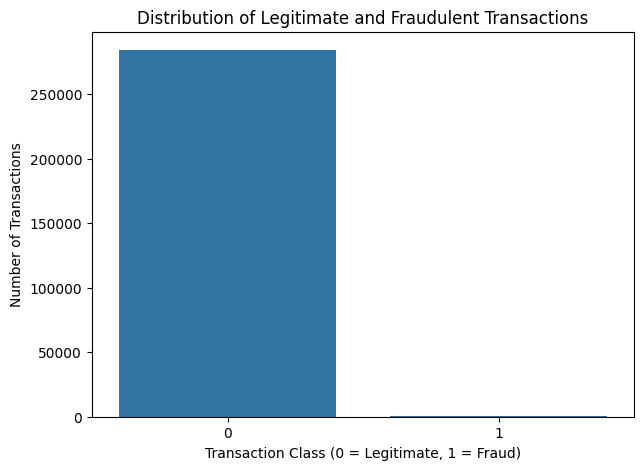

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

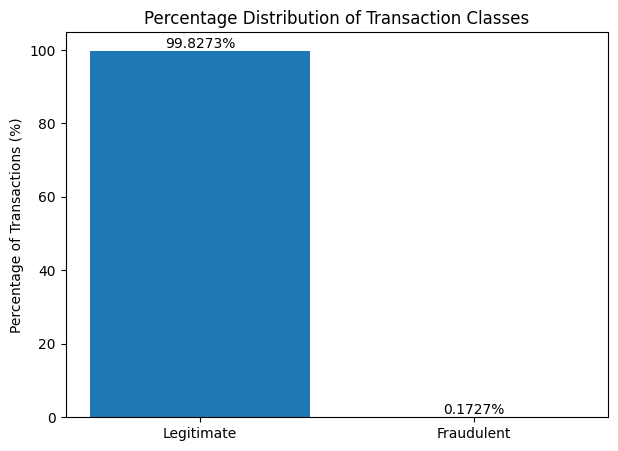

In [ ]:
class_pct = df["Class"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Legitimate", "Fraudulent"],
    class_pct.values
)

plt.title("Percentage Distribution of Transaction Classes")
plt.ylabel("Percentage of Transactions (%)")

for bar, value in zip(bars, class_pct.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.4f}%",
        ha="center",
        va="bottom"
    )

plt.show()

In [ ]:
print("=" * 60)
print("INITIAL DATA QUALITY REPORT")
print("=" * 60)

print(f"Total transactions       : {len(df):,}")
print(f"Total variables          : {df.shape[1]}")
print(f"Missing values           : {df.isnull().sum().sum():,}")
print(f"Duplicate rows           : {df.duplicated().sum():,}")
print(f"Legitimate transactions  : {(df['Class'] == 0).sum():,}")
print(f"Fraudulent transactions  : {(df['Class'] == 1).sum():,}")
print(f"Fraud rate               : {df['Class'].mean() * 100:.4f}%")

print("=" * 60)

INITIAL DATA QUALITY REPORT
Total transactions       : 284,807
Total variables          : 31
Missing values           : 0
Duplicate rows           : 1,081
Legitimate transactions  : 284,315
Fraudulent transactions  : 492
Fraud rate               : 0.1727%


In [ ]:
# Create data dictionary

data_dictionary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Description": [
        "Seconds elapsed between this transaction and the first transaction"
        if col == "Time"
        else "Transaction amount"
        if col == "Amount"
        else "Target variable: 0 = Legitimate, 1 = Fraudulent"
        if col == "Class"
        else f"Anonymized PCA-transformed feature {col}"
        for col in df.columns
    ]
})

data_dictionary

,Variable,Data Type,Description
0,Time,float64,Seconds elapsed between this transaction and t...
1,V1,float64,Anonymized PCA-transformed feature V1
2,V2,float64,Anonymized PCA-transformed feature V2
3,V3,float64,Anonymized PCA-transformed feature V3
4,V4,float64,Anonymized PCA-transformed feature V4
5,V5,float64,Anonymized PCA-transformed feature V5
6,V6,float64,Anonymized PCA-transformed feature V6
7,V7,float64,Anonymized PCA-transformed feature V7
8,V8,float64,Anonymized PCA-transformed feature V8
9,V9,float64,Anonymized PCA-transformed feature V9


In [ ]:
duplicates = df[df.duplicated(keep=False)]

print("Total rows involved in duplicate groups:", len(duplicates))

print("\nClass distribution among duplicated rows:")
print(duplicates["Class"].value_counts())

print("\nSample duplicated records:")
display(duplicates.head(10))

Total rows involved in duplicate groups: 1854

Class distribution among duplicated rows:
Class
0    1822
1      32
Name: count, dtype: int64

Sample duplicated records:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [ ]:
rows_before = len(df)

df_clean = df.drop_duplicates().copy()

rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print("Rows before cleaning :", f"{rows_before:,}")
print("Duplicates removed   :", f"{rows_removed:,}")
print("Rows after cleaning  :", f"{rows_after:,}")

print("\nClass distribution after duplicate removal:")
print(df_clean["Class"].value_counts())

print("\nFraud rate after cleaning:")
print(f"{df_clean['Class'].mean() * 100:.4f}%")

Rows before cleaning : 284,807
Duplicates removed   : 1,081
Rows after cleaning  : 283,726

Class distribution after duplicate removal:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud rate after cleaning:
0.1667%


In [ ]:
print("=" * 60)
print("POST-CLEANING DATA QUALITY CHECK")
print("=" * 60)

print(f"Rows                     : {len(df_clean):,}")
print(f"Columns                  : {df_clean.shape[1]}")
print(f"Missing values           : {df_clean.isnull().sum().sum():,}")
print(f"Remaining duplicates     : {df_clean.duplicated().sum():,}")
print(f"Legitimate transactions  : {(df_clean['Class'] == 0).sum():,}")
print(f"Fraudulent transactions  : {(df_clean['Class'] == 1).sum():,}")
print(f"Fraud rate               : {df_clean['Class'].mean() * 100:.4f}%")

print("=" * 60)

POST-CLEANING DATA QUALITY CHECK
Rows                     : 283,726
Columns                  : 31
Missing values           : 0
Remaining duplicates     : 0
Legitimate transactions  : 283,253
Fraudulent transactions  : 473
Fraud rate               : 0.1667%


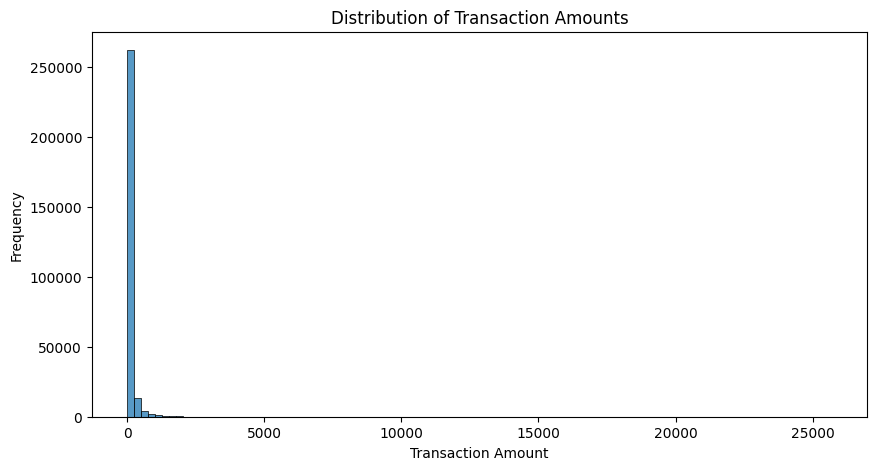

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df_clean["Amount"], bins=100)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

print(df_clean["Amount"].describe())

In [ ]:
amount_by_class = df_clean.groupby("Class")["Amount"].agg([
    "count", "mean", "median", "min", "max"
])

amount_by_class.index = ["Legitimate", "Fraudulent"]

amount_by_class

,count,mean,median,min,max
Legitimate,283253,88.413575,22.00,0.0,25691.16
Fraudulent,473,123.871860,9.82,0.0,2125.87


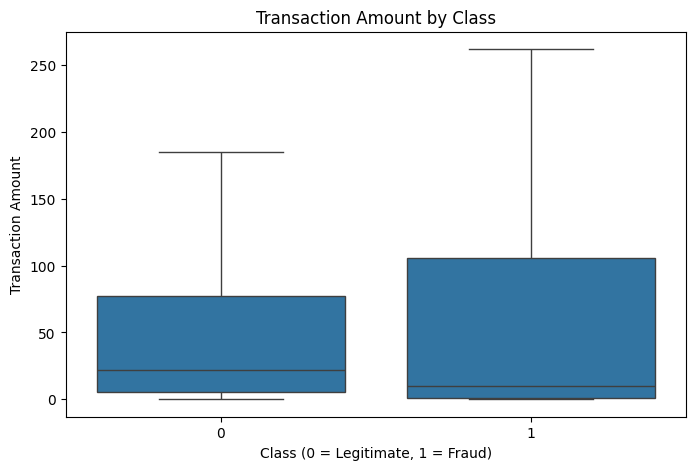

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Class",
    y="Amount",
    showfliers=False
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [ ]:
df_clean["Hour"] = (df_clean["Time"] / 3600) % 24

print("New feature 'Hour' created successfully.")

df_clean[["Time", "Hour"]].head(10)

New feature 'Hour' created successfully.


,Time,Hour
0,0.0,0.000000
1,0.0,0.000000
2,1.0,0.000278
3,1.0,0.000278
4,2.0,0.000556
5,2.0,0.000556
6,4.0,0.001111
7,7.0,0.001944
8,7.0,0.001944
9,9.0,0.002500


In [ ]:
hourly_summary = df_clean.groupby("Hour").agg(
    Total_Transactions=("Class", "count"),
    Fraud_Transactions=("Class", "sum")
)

hourly_summary["Fraud_Rate"] = (
    hourly_summary["Fraud_Transactions"] /
    hourly_summary["Total_Transactions"]
) * 100

hourly_summary.head()

,Total_Transactions,Fraud_Transactions,Fraud_Rate
Hour,,,
0.000000,3,0,0.0
0.000278,2,0,0.0
0.000278,4,0,0.0
0.000556,3,0,0.0
0.000556,2,0,0.0


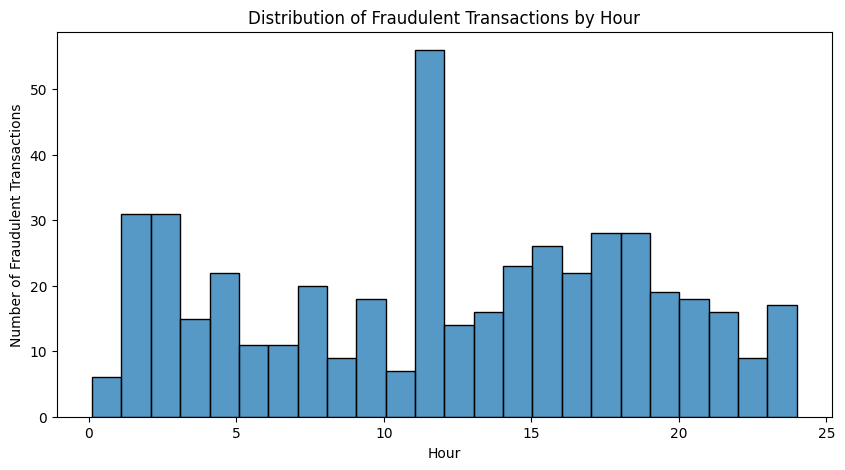

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean[df_clean["Class"] == 1],
    x="Hour",
    bins=24
)

plt.title("Distribution of Fraudulent Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

In [ ]:
correlations = (
    df_clean.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

print("Features with strongest negative correlations with fraud:")
display(correlations.head(10))

print("\nFeatures with strongest positive correlations with fraud:")
display(correlations.tail(10))

Features with strongest negative correlations with fraud:


,Class
V17,-0.313498
V14,-0.293375
V12,-0.250711
V10,-0.206971
V16,-0.187186
V3,-0.182322
V7,-0.172347
V18,-0.105340
V1,-0.094486
V9,-0.094021



Features with strongest positive correlations with fraud:


,Class
Amount,0.005777
V28,0.009682
V20,0.021486
V27,0.021892
V21,0.026357
V8,0.033068
V19,0.033631
V2,0.084624
V4,0.129326
V11,0.149067


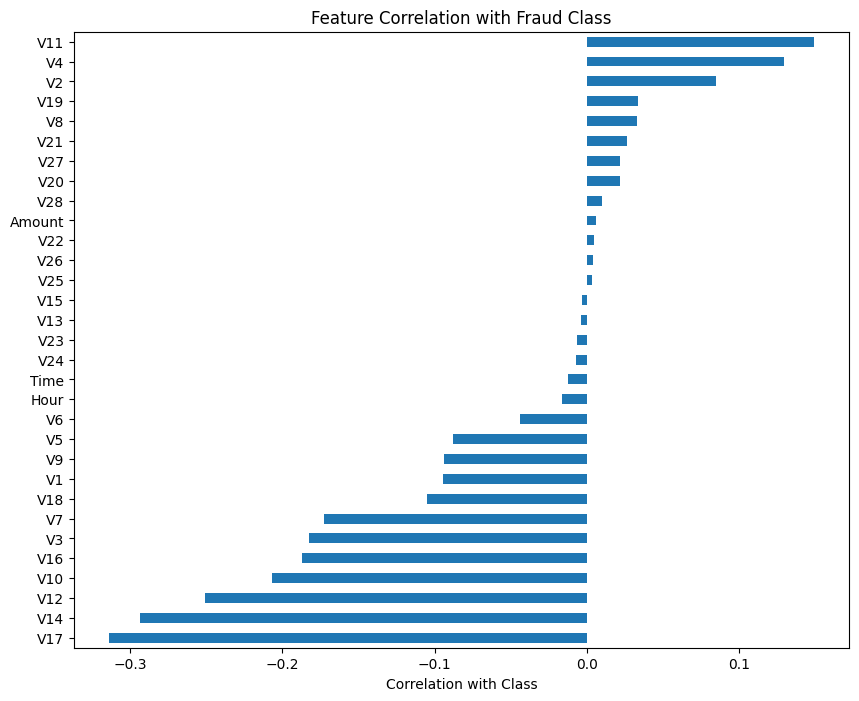

In [ ]:
plt.figure(figsize=(10, 8))

correlations.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Correlation with Class")

plt.show()

In [ ]:
Q1 = df_clean["Amount"].quantile(0.25)
Q3 = df_clean["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

amount_outliers = df_clean[
    (df_clean["Amount"] < lower_bound) |
    (df_clean["Amount"] > upper_bound)
]

print("=" * 60)
print("TRANSACTION AMOUNT OUTLIER ANALYSIS")
print("=" * 60)

print(f"Q1                       : {Q1:.2f}")
print(f"Q3                       : {Q3:.2f}")
print(f"IQR                      : {IQR:.2f}")
print(f"Lower bound              : {lower_bound:.2f}")
print(f"Upper bound              : {upper_bound:.2f}")
print(f"Potential outliers       : {len(amount_outliers):,}")
print(f"Percentage of dataset    : {len(amount_outliers)/len(df_clean)*100:.2f}%")

print("\nClass distribution among amount outliers:")
print(amount_outliers["Class"].value_counts())

print("=" * 60)

TRANSACTION AMOUNT OUTLIER ANALYSIS
Q1                       : 5.60
Q3                       : 77.51
IQR                      : 71.91
Lower bound              : -102.27
Upper bound              : 185.38
Potential outliers       : 31,685
Percentage of dataset    : 11.17%

Class distribution among amount outliers:
Class
0    31598
1       87
Name: count, dtype: int64


In [ ]:
# Define predictor variables (X) and target variable (y)

X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nFraud percentage:")
print(f"{y.mean() * 100:.4f}%")

Feature matrix shape: (283726, 31)
Target shape: (283726,)

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud percentage:
0.1667%


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training transactions : {len(X_train):,}")
print(f"Testing transactions  : {len(X_test):,}")

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTraining fraud rate:")
print(f"{y_train.mean() * 100:.4f}%")

print("\nTesting fraud rate:")
print(f"{y_test.mean() * 100:.4f}%")

TRAIN / TEST SPLIT
Training transactions : 226,980
Testing transactions  : 56,746

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Training fraud rate:
0.1665%

Testing fraud rate:
0.1674%


In [ ]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

overlap = X_train.index.intersection(X_test.index)

print("Overlapping row indices:", len(overlap))

if len(overlap) == 0:
    print("PASS: No transaction appears in both training and test sets.")
else:
    print("WARNING: Possible data leakage detected.")

Training set shape: (226980, 31)
Test set shape: (56746, 31)
Overlapping row indices: 0
PASS: No transaction appears in both training and test sets.


In [ ]:
# Create copies to preserve the original split

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scale_columns = ["Time", "Amount", "Hour"]

scaler = StandardScaler()

# Fit ONLY on training data to prevent data leakage
X_train_scaled[scale_columns] = scaler.fit_transform(
    X_train[scale_columns]
)

# Apply the training transformation to test data
X_test_scaled[scale_columns] = scaler.transform(
    X_test[scale_columns]
)

print("Scaling completed successfully.")

print("\nScaled training features:")
display(X_train_scaled[scale_columns].describe().T)

Scaling completed successfully.

Scaled training features:


,count,mean,std,min,25%,50%,75%,max
Time,226980.0,-1.518880e-16,1.000002,-1.998400,-0.856182,-0.212353,0.936319,1.640237
Amount,226980.0,7.309531e-17,1.000002,-0.359639,-0.336487,-0.269797,-0.042875,79.620870
Hour,226980.0,-2.545579e-16,1.000002,-2.490956,-0.674707,0.079963,0.820410,1.618842


fit_transform → training set
transform → test set

In [ ]:
from sklearn.ensemble import RandomForestClassifier

feature_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

feature_selector.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": feature_selector.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
14,V14,0.195619
10,V10,0.145984
12,V12,0.106124
4,V4,0.083001
11,V11,0.078928
17,V17,0.066160
3,V3,0.049164
16,V16,0.035570
7,V7,0.029526
2,V2,0.025602


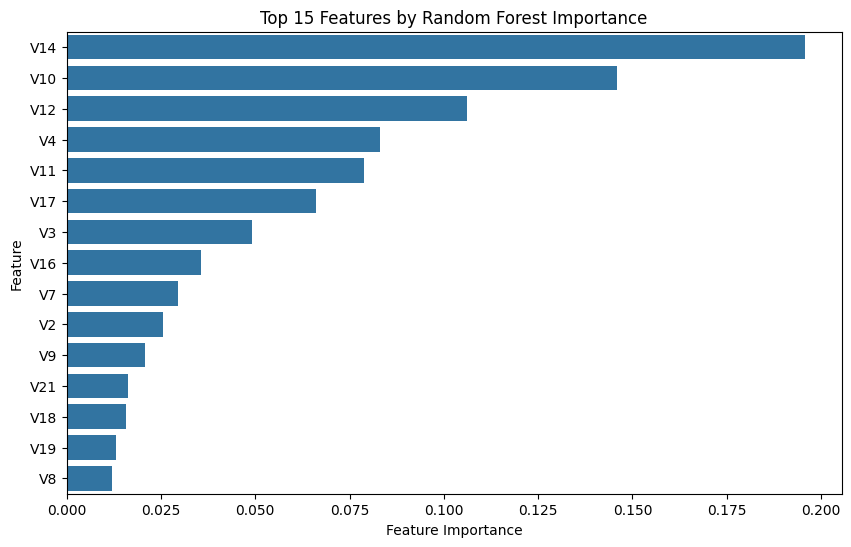

In [ ]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features by Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Use only V1-V28 for the PCA visualisation
pca_features = [f"V{i}" for i in range(1, 29)]

pca_visualizer = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_train_pca = pca_visualizer.fit_transform(
    X_train_scaled[pca_features]
)

pca_df = pd.DataFrame({
    "PC1": X_train_pca[:, 0],
    "PC2": X_train_pca[:, 1],
    "Class": y_train.values
})

print("Explained variance ratio:")
print(pca_visualizer.explained_variance_ratio_)

print(
    "\nTotal variance explained:",
    pca_visualizer.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.12531051 0.08989476]

Total variance explained: 0.21520526964607228


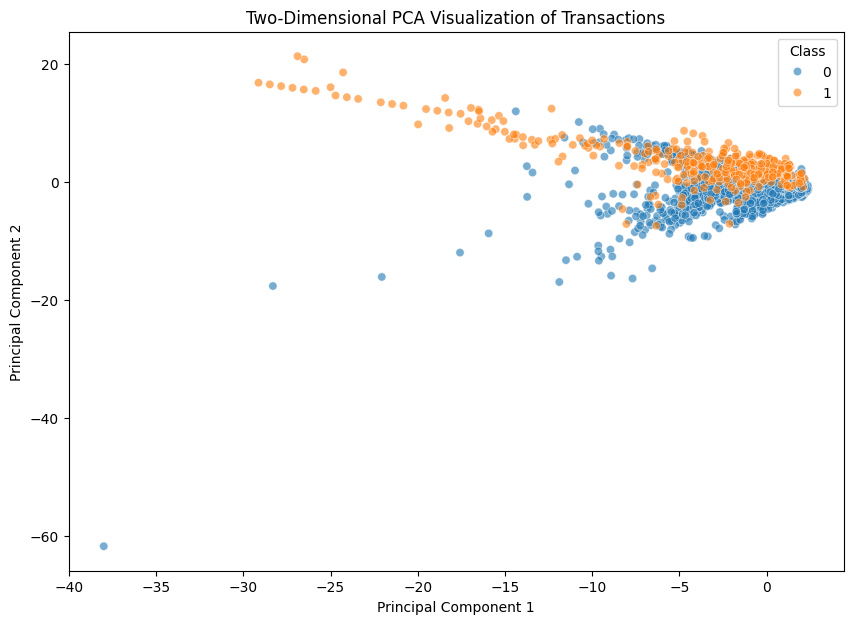

In [ ]:
# Sample legitimate transactions for clearer visualisation
legitimate_sample = pca_df[pca_df["Class"] == 0].sample(
    n=min(10000, (pca_df["Class"] == 0).sum()),
    random_state=RANDOM_STATE
)

fraud_sample = pca_df[pca_df["Class"] == 1]

pca_plot_data = pd.concat([
    legitimate_sample,
    fraud_sample
])

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_plot_data,
    x="PC1",
    y="PC2",
    hue="Class",
    alpha=0.6
)

plt.title("Two-Dimensional PCA Visualization of Transactions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
class_weight="balanced"

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


In [ ]:
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_pr_auc = average_precision_score(
    y_test,
    logistic_probabilities
)

print("=" * 60)
print("LOGISTIC REGRESSION — TEST SET PERFORMANCE")
print("=" * 60)

print(f"Accuracy   : {logistic_accuracy:.4f}")
print(f"Precision  : {logistic_precision:.4f}")
print(f"Recall     : {logistic_recall:.4f}")
print(f"F1 Score   : {logistic_f1:.4f}")
print(f"ROC-AUC    : {logistic_roc_auc:.4f}")
print(f"PR-AUC     : {logistic_pr_auc:.4f}")

print("=" * 60)

LOGISTIC REGRESSION — TEST SET PERFORMANCE
Accuracy   : 0.9748
Precision  : 0.0552
Recall     : 0.8737
F1 Score   : 0.1039
ROC-AUC    : 0.9686
PR-AUC     : 0.6704


In [ ]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Legitimate", "Fraud"]
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746



In [ ]:
cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nBusiness Interpretation")
print("-" * 40)

print(f"True Negatives  (correct legitimate) : {tn:,}")
print(f"False Positives (false fraud alerts) : {fp:,}")
print(f"False Negatives (missed fraud)       : {fn:,}")
print(f"True Positives  (fraud detected)     : {tp:,}")

Confusion Matrix:
[[55231  1420]
 [   12    83]]

Business Interpretation
----------------------------------------
True Negatives  (correct legitimate) : 55,231
False Positives (false fraud alerts) : 1,420
False Negatives (missed fraud)       : 12
True Positives  (fraud detected)     : 83


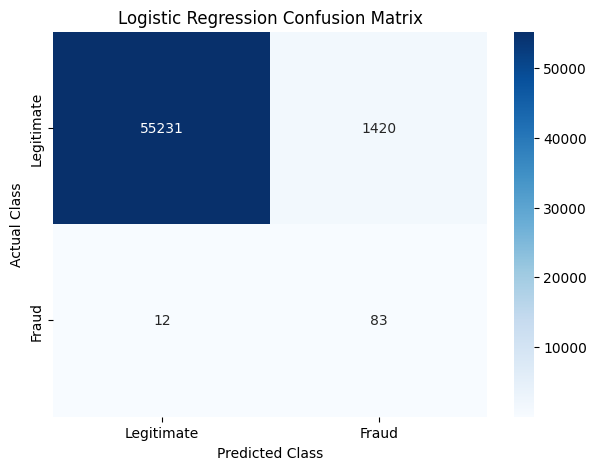

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
model_results = []

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1": logistic_f1,
    "ROC-AUC": logistic_roc_auc,
    "PR-AUC": logistic_pr_auc
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.974765,0.055223,0.873684,0.10388,0.968558,0.670385


In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

decision_tree_model.fit(
    X_train_scaled,
    y_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [ ]:
dt_predictions = decision_tree_model.predict(X_test_scaled)
dt_probabilities = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions, zero_division=0)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)
dt_roc_auc = roc_auc_score(y_test, dt_probabilities)
dt_pr_auc = average_precision_score(y_test, dt_probabilities)

print("=" * 60)
print("DECISION TREE — TEST SET PERFORMANCE")
print("=" * 60)

print(f"Accuracy   : {dt_accuracy:.4f}")
print(f"Precision  : {dt_precision:.4f}")
print(f"Recall     : {dt_recall:.4f}")
print(f"F1 Score   : {dt_f1:.4f}")
print(f"ROC-AUC    : {dt_roc_auc:.4f}")
print(f"PR-AUC     : {dt_pr_auc:.4f}")

print("=" * 60)

DECISION TREE — TEST SET PERFORMANCE
Accuracy   : 0.9952
Precision  : 0.2284
Recall     : 0.7789
F1 Score   : 0.3532
ROC-AUC    : 0.8887
PR-AUC     : 0.5378


In [ ]:
dt_cm = confusion_matrix(y_test, dt_predictions)

dt_tn, dt_fp, dt_fn, dt_tp = dt_cm.ravel()

print("Decision Tree Confusion Matrix:")
print(dt_cm)

print("\nBusiness Interpretation")
print("-" * 40)

print(f"Correct legitimate transactions : {dt_tn:,}")
print(f"False fraud alerts              : {dt_fp:,}")
print(f"Missed fraud                    : {dt_fn:,}")
print(f"Fraud detected                  : {dt_tp:,}")

Decision Tree Confusion Matrix:
[[56401   250]
 [   21    74]]

Business Interpretation
----------------------------------------
Correct legitimate transactions : 56,401
False fraud alerts              : 250
Missed fraud                    : 21
Fraud detected                  : 74


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_scaled,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
rf_predictions = random_forest_model.predict(X_test_scaled)
rf_probabilities = random_forest_model.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, zero_division=0)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)
rf_pr_auc = average_precision_score(y_test, rf_probabilities)

print("=" * 60)
print("RANDOM FOREST — TEST SET PERFORMANCE")
print("=" * 60)

print(f"Accuracy   : {rf_accuracy:.4f}")
print(f"Precision  : {rf_precision:.4f}")
print(f"Recall     : {rf_recall:.4f}")
print(f"F1 Score   : {rf_f1:.4f}")
print(f"ROC-AUC    : {rf_roc_auc:.4f}")
print(f"PR-AUC     : {rf_pr_auc:.4f}")

print("=" * 60)

RANDOM FOREST — TEST SET PERFORMANCE
Accuracy   : 0.9995
Precision  : 0.9324
Recall     : 0.7263
F1 Score   : 0.8166
ROC-AUC    : 0.9473
PR-AUC     : 0.8051


In [ ]:
rf_cm = confusion_matrix(y_test, rf_predictions)

rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

print("Random Forest Confusion Matrix:")
print(rf_cm)

print("\nBusiness Interpretation")
print("-" * 40)

print(f"Correct legitimate transactions : {rf_tn:,}")
print(f"False fraud alerts              : {rf_fp:,}")
print(f"Missed fraud                    : {rf_fn:,}")
print(f"Fraud detected                  : {rf_tp:,}")

Random Forest Confusion Matrix:
[[56646     5]
 [   26    69]]

Business Interpretation
----------------------------------------
Correct legitimate transactions : 56,646
False fraud alerts              : 5
Missed fraud                    : 26
Fraud detected                  : 69


In [ ]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"Legitimate training transactions : {negative_count:,}")
print(f"Fraud training transactions      : {positive_count:,}")
print(f"scale_pos_weight                 : {scale_pos_weight:.2f}")

Legitimate training transactions : 226,602
Fraud training transactions      : 378
scale_pos_weight                 : 599.48


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
xgb_predictions = xgb_model.predict(X_test_scaled)
xgb_probabilities = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions, zero_division=0)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)
xgb_roc_auc = roc_auc_score(y_test, xgb_probabilities)
xgb_pr_auc = average_precision_score(y_test, xgb_probabilities)

print("=" * 60)
print("XGBOOST — TEST SET PERFORMANCE")
print("=" * 60)

print(f"Accuracy   : {xgb_accuracy:.4f}")
print(f"Precision  : {xgb_precision:.4f}")
print(f"Recall     : {xgb_recall:.4f}")
print(f"F1 Score   : {xgb_f1:.4f}")
print(f"ROC-AUC    : {xgb_roc_auc:.4f}")
print(f"PR-AUC     : {xgb_pr_auc:.4f}")

print("=" * 60)

XGBOOST — TEST SET PERFORMANCE
Accuracy   : 0.9994
Precision  : 0.8462
Recall     : 0.8105
F1 Score   : 0.8280
ROC-AUC    : 0.9752
PR-AUC     : 0.8151


In [ ]:
xgb_cm = confusion_matrix(y_test, xgb_predictions)

xgb_tn, xgb_fp, xgb_fn, xgb_tp = xgb_cm.ravel()

print("XGBoost Confusion Matrix:")
print(xgb_cm)

print("\nBusiness Interpretation")
print("-" * 40)

print(f"Correct legitimate transactions : {xgb_tn:,}")
print(f"False fraud alerts              : {xgb_fp:,}")
print(f"Missed fraud                    : {xgb_fn:,}")
print(f"Fraud detected                  : {xgb_tp:,}")

XGBoost Confusion Matrix:
[[56637    14]
 [   18    77]]

Business Interpretation
----------------------------------------
Correct legitimate transactions : 56,637
False fraud alerts              : 14
Missed fraud                    : 18
Fraud detected                  : 77


In [ ]:
model_results.extend([
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1": dt_f1,
        "ROC-AUC": dt_roc_auc,
        "PR-AUC": dt_pr_auc
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1,
        "ROC-AUC": rf_roc_auc,
        "PR-AUC": rf_pr_auc
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_accuracy,
        "Precision": xgb_precision,
        "Recall": xgb_recall,
        "F1": xgb_f1,
        "ROC-AUC": xgb_roc_auc,
        "PR-AUC": xgb_pr_auc
    }
])

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.9994,0.8462,0.8105,0.8280,0.9752,0.8151
1,Random Forest,0.9995,0.9324,0.7263,0.8166,0.9473,0.8051
2,Logistic Regression,0.9748,0.0552,0.8737,0.1039,0.9686,0.6704
3,Decision Tree,0.9952,0.2284,0.7789,0.3532,0.8887,0.5378


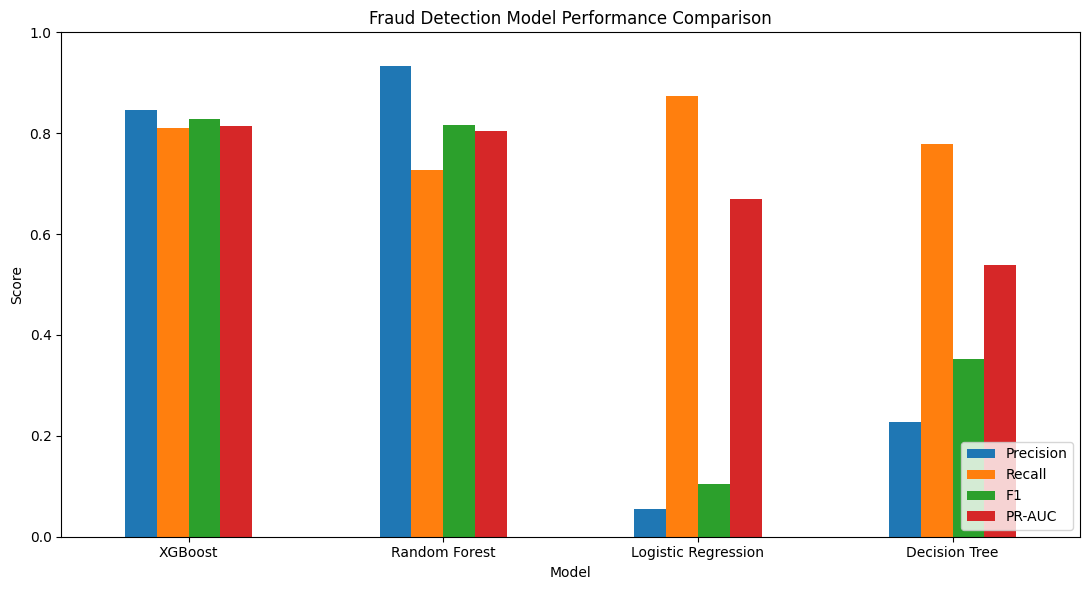

In [ ]:
comparison_plot = results_df.set_index("Model")[
    ["Precision", "Recall", "F1", "PR-AUC"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Fraud Detection Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

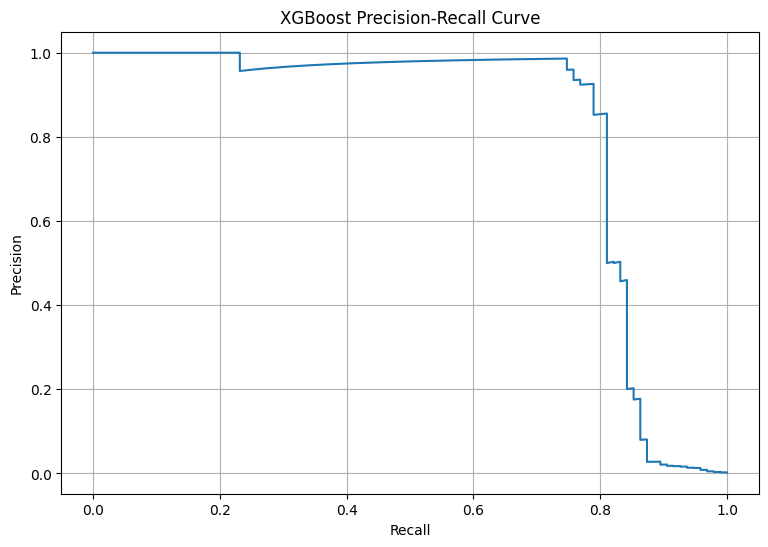

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    xgb_probabilities
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.title("XGBoost Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)

plt.show()

In [ ]:
threshold_f1_scores = (
    2 * precision_values[:-1] * recall_values[:-1]
    /
    (precision_values[:-1] + recall_values[:-1] + 1e-10)
)

best_index = np.argmax(threshold_f1_scores)

best_threshold = thresholds[best_index]
best_precision = precision_values[best_index]
best_recall = recall_values[best_index]
best_f1 = threshold_f1_scores[best_index]

print("=" * 60)
print("THRESHOLD OPTIMIZATION — MAXIMUM F1")
print("=" * 60)

print(f"Optimal threshold : {best_threshold:.4f}")
print(f"Precision         : {best_precision:.4f}")
print(f"Recall            : {best_recall:.4f}")
print(f"F1 Score          : {best_f1:.4f}")

print("=" * 60)

THRESHOLD OPTIMIZATION — MAXIMUM F1
Optimal threshold : 0.8042
Precision         : 0.9259
Recall            : 0.7895
F1 Score          : 0.8523


In [ ]:
optimized_predictions = (
    xgb_probabilities >= best_threshold
).astype(int)

optimized_cm = confusion_matrix(
    y_test,
    optimized_predictions
)

opt_tn, opt_fp, opt_fn, opt_tp = optimized_cm.ravel()

print("=" * 60)
print("OPTIMIZED XGBOOST CONFUSION MATRIX")
print("=" * 60)

print(optimized_cm)

print("\nBusiness Interpretation")
print("-" * 40)

print(f"Correct legitimate transactions : {opt_tn:,}")
print(f"False fraud alerts              : {opt_fp:,}")
print(f"Missed fraud                    : {opt_fn:,}")
print(f"Fraud detected                  : {opt_tp:,}")

print("=" * 60)

OPTIMIZED XGBOOST CONFUSION MATRIX
[[56645     6]
 [   20    75]]

Business Interpretation
----------------------------------------
Correct legitimate transactions : 56,645
False fraud alerts              : 6
Missed fraud                    : 20
Fraud detected                  : 75


In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)

# Use a sample to keep computation manageable
X_shap = X_test_scaled.sample(
    n=min(5000, len(X_test_scaled)),
    random_state=RANDOM_STATE
)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully.")
print("SHAP sample size:", len(X_shap))

SHAP values calculated successfully.
SHAP sample size: 5000


/tmp/ipykernel_1327/404450336.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


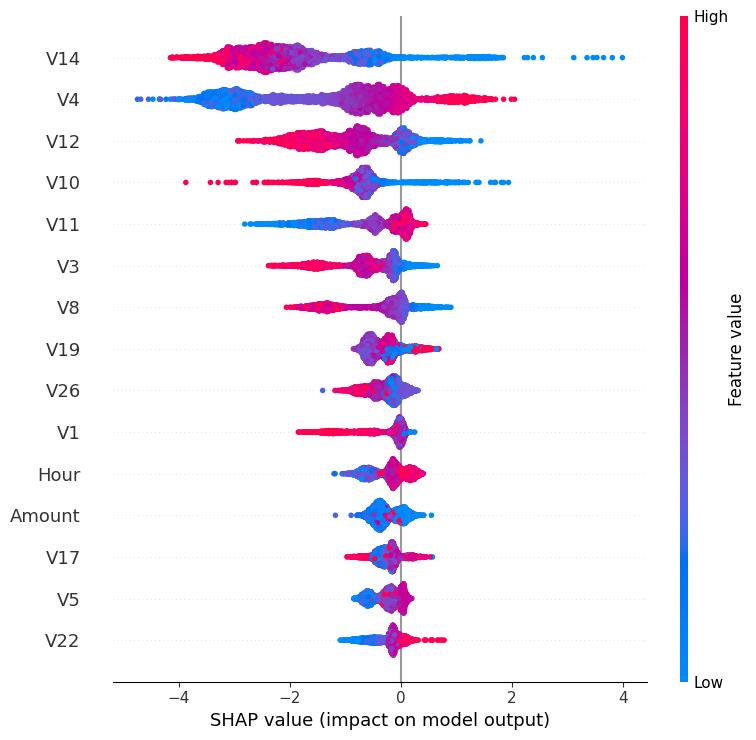

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15
)

In [ ]:
xgb_train_probabilities = xgb_model.predict_proba(
    X_train_scaled
)[:, 1]

train_pr_auc = average_precision_score(
    y_train,
    xgb_train_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    xgb_probabilities
)

train_roc_auc = roc_auc_score(
    y_train,
    xgb_train_probabilities
)

test_roc_auc = roc_auc_score(
    y_test,
    xgb_probabilities
)

print("=" * 60)
print("XGBOOST OVERFITTING CHECK")
print("=" * 60)

print(f"Training PR-AUC : {train_pr_auc:.4f}")
print(f"Testing PR-AUC  : {test_pr_auc:.4f}")

print()

print(f"Training ROC-AUC: {train_roc_auc:.4f}")
print(f"Testing ROC-AUC : {test_roc_auc:.4f}")

print()

print(
    f"PR-AUC gap      : "
    f"{train_pr_auc - test_pr_auc:.4f}"
)

print("=" * 60)

XGBOOST OVERFITTING CHECK
Training PR-AUC : 0.9970
Testing PR-AUC  : 0.8151

Training ROC-AUC: 1.0000
Testing ROC-AUC : 0.9752

PR-AUC gap      : 0.1819


In [ ]:
fairness_df = X_test.copy()

fairness_df["Actual_Class"] = y_test.values
fairness_df["Predicted_Class"] = xgb_predictions

fairness_df["Amount_Group"] = pd.qcut(
    fairness_df["Amount"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ],
    duplicates="drop"
)

fairness_df["Amount_Group"].value_counts()

,count
Amount_Group,
Low,14245
High,14187
Medium-High,14186
Medium-Low,14128


In [ ]:
segment_results = []

for group in fairness_df["Amount_Group"].dropna().unique():

    segment = fairness_df[
        fairness_df["Amount_Group"] == group
    ]

    actual = segment["Actual_Class"]
    predicted = segment["Predicted_Class"]

    fraud_count = actual.sum()

    segment_results.append({
        "Amount Group": group,
        "Transactions": len(segment),
        "Actual Fraud": fraud_count,
        "Precision": precision_score(
            actual,
            predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            actual,
            predicted,
            zero_division=0
        ),
        "F1": f1_score(
            actual,
            predicted,
            zero_division=0
        )
    })

segment_results_df = pd.DataFrame(segment_results)

display(segment_results_df)

,Amount Group,Transactions,Actual Fraud,Precision,Recall,F1
0,Medium-Low,14128,6,0.625000,0.833333,0.714286
1,Low,14245,44,0.871795,0.772727,0.819277
2,High,14187,33,0.812500,0.787879,0.800000
3,Medium-High,14186,12,1.000000,1.000000,1.000000


In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    xgb_model,
    "models/xgboost_fraud_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

print("Model artifacts saved successfully.")

print(
    os.listdir("models")
)

Model artifacts saved successfully.
['xgboost_fraud_model.pkl', 'scaler.pkl']


In [ ]:
from xgboost import XGBClassifier

regularized_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

regularized_xgb.fit(X_train_scaled, y_train)

print("Regularized XGBoost training completed.")

Regularized XGBoost training completed.


In [ ]:
reg_test_probabilities = regularized_xgb.predict_proba(X_test_scaled)[:, 1]
reg_test_predictions = regularized_xgb.predict(X_test_scaled)

reg_accuracy = accuracy_score(y_test, reg_test_predictions)
reg_precision = precision_score(y_test, reg_test_predictions, zero_division=0)
reg_recall = recall_score(y_test, reg_test_predictions)
reg_f1 = f1_score(y_test, reg_test_predictions)
reg_roc_auc = roc_auc_score(y_test, reg_test_probabilities)
reg_pr_auc = average_precision_score(y_test, reg_test_probabilities)

print("=" * 60)
print("REGULARIZED XGBOOST — TEST PERFORMANCE")
print("=" * 60)

print(f"Accuracy   : {reg_accuracy:.4f}")
print(f"Precision  : {reg_precision:.4f}")
print(f"Recall     : {reg_recall:.4f}")
print(f"F1 Score   : {reg_f1:.4f}")
print(f"ROC-AUC    : {reg_roc_auc:.4f}")
print(f"PR-AUC     : {reg_pr_auc:.4f}")

print("=" * 60)

REGULARIZED XGBOOST — TEST PERFORMANCE
Accuracy   : 0.9902
Precision  : 0.1298
Recall     : 0.8526
F1 Score   : 0.2253
ROC-AUC    : 0.9793
PR-AUC     : 0.6733
